# $$\text{Single layer A.N.N. exercise}$$

The data is stored in 'dataExercise1.txt', which contains 1000 points. The first three columns represent the input variables, whilst the three last columns represent the output variables.

The Artificial Neural Network (A.N.N.) we want to build

1. Three input and output variables.
2. The activiation function should be defined as rectified linear units (relu).
3. The output layer should be defined by linear activation function (linear).
4. Set the number of neurons and epochs to 50.

#### $$\text{1 - Importing the necessary python modules}$$

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import time

import torch
import torch.optim as optim
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

#### $$\text{GPU Acceleration with CUDA}$$

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### $$\text{2 - Splitting the data}$$

In [43]:
data = np.loadtxt('dataExercise1.txt')

In [44]:
inputData, outputData = data[:, 0:3], data[:, 3:6]

In [45]:
X = torch.tensor(inputData, dtype=torch.float32)
y = torch.tensor(outputData, dtype=torch.float32)

#### $$\text{3 - Creating the single layer A.N.N.}$$

In [46]:
class SingleLayerANN(nn.Module):
    def __init__(self, numHidden=50):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(3, numHidden),           # 3 inputs, 50 hidden neurons
            nn.ReLU(),                         # ReLU activation
            nn.Linear(numHidden, 3)            # 3 outputs, linear activation
        )

    def forward(self, x):
        return self.model(x)

The default ``` batch_size ```, if not defined, is the entire dataset tensor passed through the model. Therefore, we use DataLoader to define a matching batch size to TensorFlow (which is by default 32).

In [47]:
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [48]:
model = SingleLayerANN().to(device)

In [49]:
lossFunction = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### $$\text{4 - Training run}$$

In [50]:
epochs = 50

Before training the model, we call ```model.train()``` to enter into training mode. Apparently some of the layers behaves differently during training and evaluation. 

PyTorch computes the gradient of the loss with respect to each trainable model parameter. ```loss.backward()``` performs backpropagation.

In [51]:
for epoch in range(epochs):
    model.train()

    epoch_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        prediction = model(X_batch)

        loss = lossFunction(prediction, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_epoch_loss = epoch_loss / len(loader)

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {average_epoch_loss:.6f}")

Epoch 1/50, Loss: 0.025854
Epoch 2/50, Loss: 0.015465
Epoch 3/50, Loss: 0.010662
Epoch 4/50, Loss: 0.007829
Epoch 5/50, Loss: 0.006825
Epoch 6/50, Loss: 0.006233
Epoch 7/50, Loss: 0.006100
Epoch 8/50, Loss: 0.005791
Epoch 9/50, Loss: 0.005607
Epoch 10/50, Loss: 0.005285
Epoch 11/50, Loss: 0.004886
Epoch 12/50, Loss: 0.004660
Epoch 13/50, Loss: 0.004397
Epoch 14/50, Loss: 0.004290
Epoch 15/50, Loss: 0.003880
Epoch 16/50, Loss: 0.003675
Epoch 17/50, Loss: 0.003277
Epoch 18/50, Loss: 0.003063
Epoch 19/50, Loss: 0.002844
Epoch 20/50, Loss: 0.002716
Epoch 21/50, Loss: 0.002555
Epoch 22/50, Loss: 0.002269
Epoch 23/50, Loss: 0.002092
Epoch 24/50, Loss: 0.002028
Epoch 25/50, Loss: 0.001900
Epoch 26/50, Loss: 0.001755
Epoch 27/50, Loss: 0.001644
Epoch 28/50, Loss: 0.001560
Epoch 29/50, Loss: 0.001482
Epoch 30/50, Loss: 0.001394
Epoch 31/50, Loss: 0.001343
Epoch 32/50, Loss: 0.001250
Epoch 33/50, Loss: 0.001211
Epoch 34/50, Loss: 0.001130
Epoch 35/50, Loss: 0.001076
Epoch 36/50, Loss: 0.001032
E

#### $$\text{5 - Visualizing the accuracy}$$

The operation ``` detach().cpu().numpy() ``` is applied from the left to right. 

1. ```detach()``` removes the tensors from PyTorch computation graph. Calling it creates a new tensor with the same numerical values, but without gradient tracking.

2. ```cpu()``` moves the GPU memory to CPU memory. 

3. ```numpy()``` converts the CPU tensor to a numpy array.

In [52]:
model.eval()

with torch.no_grad():
    X_device = X.to(device)
    prediction = model(X_device)

# Convert only when needed for plotting
prediction_np = prediction.detach().cpu().numpy()
y_np = y.detach().cpu().numpy()

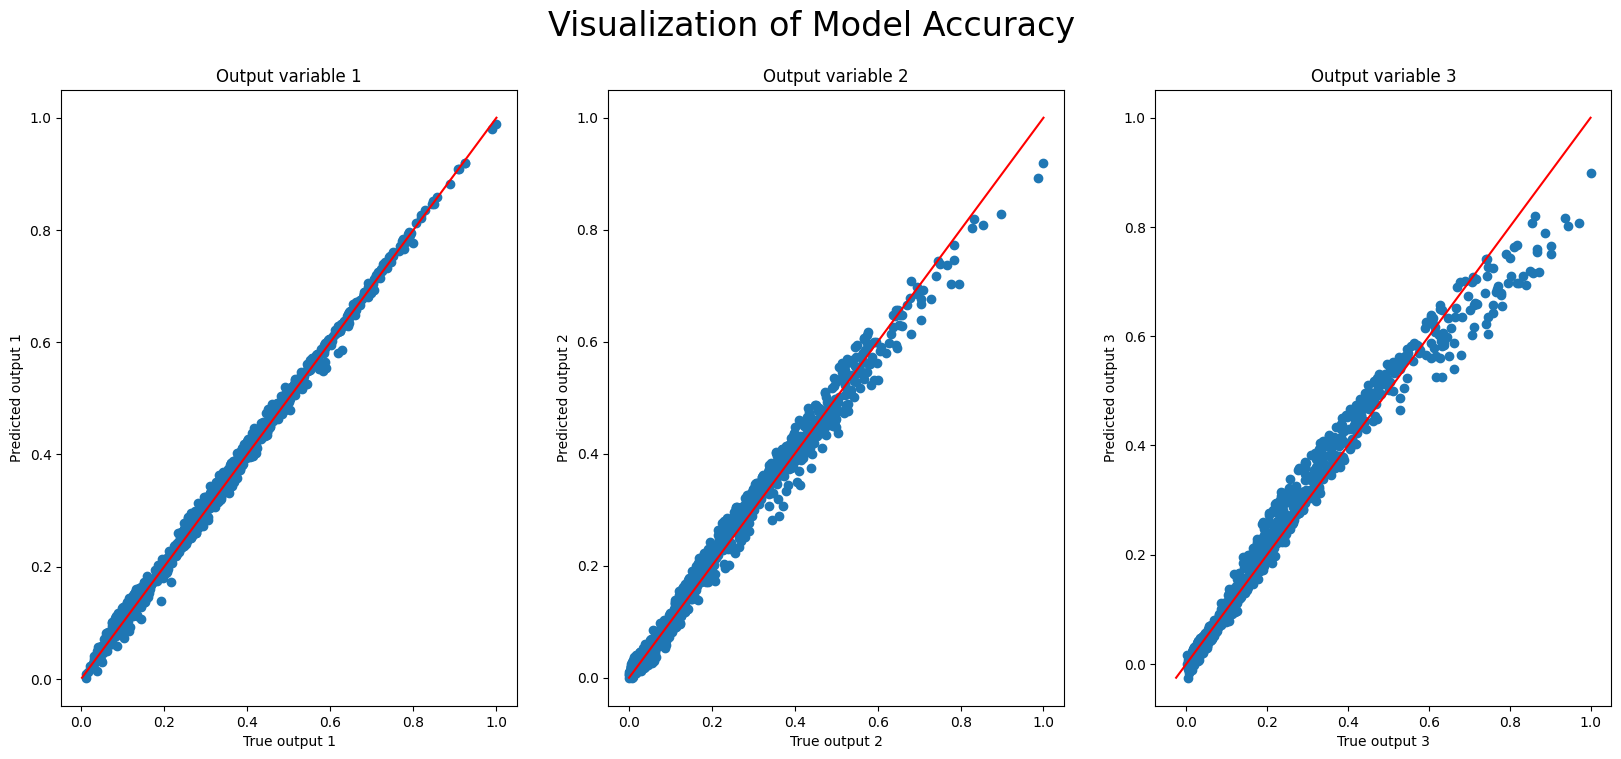

In [53]:
fig, ax = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle("Visualization of Model Accuracy", fontsize=24)

for i in range(3):
    ax[i].scatter(y_np[:, i], prediction_np[:, i])

    min_val = min(y_np[:, i].min(), prediction_np[:, i].min())
    max_val = max(y_np[:, i].max(), prediction_np[:, i].max())

    ax[i].plot([min_val, max_val], [min_val, max_val], color="r")

    ax[i].set_xlabel(f"True output {i + 1}")
    ax[i].set_ylabel(f"Predicted output {i + 1}")
    ax[i].set_title(f"Output variable {i + 1}")

plt.show()